# SatwaVision Training


## 1. Cek GPU aktif

In [ ]:
!nvidia-smi
import tensorflow as tf
print("GPU terdeteksi:", tf.config.list_physical_devices('GPU'))

Fri Jul 31 11:36:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Mount Google Drive
Drive dipakai untuk membaca dataset dan menyimpan hasil model, supaya tidak hilang saat runtime Colab direset.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Siapkan dataset
Digunakan untuk membaca dataset (gambar) yang disimpan di dalam g-drive

In [ ]:
import zipfile, os

DATASET_DIR = "/content/drive/MyDrive/klasifikasi/Dataset"

# Cek isi folder
for cls in os.listdir(DATASET_DIR):
    cls_path = os.path.join(DATASET_DIR, cls)
    if os.path.isdir(cls_path):
        print(f"{cls}: {len(os.listdir(cls_path))} gambar")

tupai: 1862 gambar
kupu-kupu: 2112 gambar
sapi: 1866 gambar
laba-laba: 4821 gambar
kucing: 1668 gambar
anjing: 4863 gambar
kuda: 2623 gambar
gajah: 1446 gambar
domba: 1820 gambar
ayam: 3098 gambar


In [ ]:
print(os.listdir("/content/drive/MyDrive/klasifikasi/Dataset"))

['tupai', 'kupu-kupu', 'sapi', 'laba-laba', 'kucing', 'anjing', 'kuda', 'gajah', 'domba', 'ayam']


## 4. Konfigurasi

In [ ]:
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import os

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

EPOCHS_HEAD = 12
LR_HEAD = 1e-3

EPOCHS_FINE_TUNE = 15
LR_FINE_TUNE = 1e-5
FINE_TUNE_AT_LAYER = 100

# Folder untuk simpan model
OUTPUT_DIR = "/content/drive/MyDrive/satwavision/model"
WEB_MODEL_DIR = "/content/drive/MyDrive/satwavision/web_model"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(WEB_MODEL_DIR, exist_ok=True)

## 5. Load dataset + augmentasi

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

class_names = train_ds.class_names
print("Kelas terdeteksi:", class_names)

with open(os.path.join(OUTPUT_DIR, "class_indices.json"), "w") as f:
    json.dump(class_names, f, indent=2)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name="data_augmentation")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 26179 files belonging to 10 classes.
Using 20944 files for training.
Found 26179 files belonging to 10 classes.
Using 5235 files for validation.
Kelas terdeteksi: ['anjing', 'ayam', 'domba', 'gajah', 'kucing', 'kuda', 'kupu-kupu', 'laba-laba', 'sapi', 'tupai']


## 6. Bangun model (Transfer Learning dari MobileNetV2 pretrained)

In [ ]:
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = models.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_HEAD),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_accuracy"),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, monitor="val_loss"),
]

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 7. Tahap 1 — Latih classifier head (base model dibekukan)

In [ ]:
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks,
)

Epoch 1/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 147s 215ms/step - accuracy: 0.8520 - loss: 0.4693 - val_accuracy: 0.9530 - val_loss: 0.1600 - learning_rate: 0.0010
Epoch 2/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 102s 156ms/step - accuracy: 0.8974 - loss: 0.3199 - val_accuracy: 0.9559 - val_loss: 0.1510 - learning_rate: 0.0010
Epoch 3/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 101s 155ms/step - accuracy: 0.9055 - loss: 0.2906 - val_accuracy: 0.9557 - val_loss: 0.1529 - learning_rate: 0.0010
Epoch 4/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 146s 161ms/step - accuracy: 0.9075 - loss: 0.2796 - val_accuracy: 0.9580 - val_loss: 0.1428 - learning_rate: 0.0010
Epoch 5/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 103s 158ms/step - accuracy: 0.9135 - loss: 0.2674 - val_accuracy: 0.9580 - val_loss: 0.1439 - learning_rate: 0.0010
Epoch 6/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 107s 164ms/step - accuracy: 0.9144 - loss: 0.2573 - val_accuracy: 0.9555 - val_loss: 0.1478 - learning_rate: 0.0010
Epoch 7/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 105s 160ms/step - accura

## 8. Tahap 2 — Fine-tuning (buka sebagian layer MobileNetV2)


In [ ]:
base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT_LAYER]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_FINE_TUNE),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE_TUNE,
    callbacks=callbacks,
)

Epoch 1/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 150s 208ms/step - accuracy: 0.8871 - loss: 0.3522 - val_accuracy: 0.9616 - val_loss: 0.1366 - learning_rate: 1.0000e-05
Epoch 2/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 117s 179ms/step - accuracy: 0.9105 - loss: 0.2747 - val_accuracy: 0.9622 - val_loss: 0.1336 - learning_rate: 1.0000e-05
Epoch 3/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 115s 175ms/step - accuracy: 0.9200 - loss: 0.2455 - val_accuracy: 0.9647 - val_loss: 0.1286 - learning_rate: 1.0000e-05
Epoch 4/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 114s 174ms/step - accuracy: 0.9266 - loss: 0.2216 - val_accuracy: 0.9645 - val_loss: 0.1255 - learning_rate: 1.0000e-05
Epoch 5/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 119s 181ms/step - accuracy: 0.9340 - loss: 0.2015 - val_accuracy: 0.9650 - val_loss: 0.1250 - learning_rate: 1.0000e-05
Epoch 6/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 116s 177ms/step - accuracy: 0.9360 - loss: 0.1981 - val_accuracy: 0.9656 - val_loss: 0.1240 - learning_rate: 1.0000e-05
Epoch 7/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 

## 9. Simpan model ke Google Drive
simpan model, agar jika runtime terputus tidak ulang dari awal

In [ ]:
model_path = os.path.join(OUTPUT_DIR, "animal_classifier1.keras")
model.save(model_path)
print("Model tersimpan di:", model_path)

Model tersimpan di: /content/drive/MyDrive/satwavision/model/animal_classifier1.keras


## 10. Evaluasi model

In [ ]:
y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print("=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_names))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_true, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

      anjing       0.98      0.96      0.97       956
        ayam       0.98      0.99      0.99       608
       domba       0.94      0.94      0.94       324
       gajah       0.96      0.98      0.97       304
      kucing       0.95      0.96      0.96       346
        kuda       0.97      0.96      0.97       502
   kupu-kupu       0.97      0.99      0.98       409
   laba-laba       0.99      0.98      0.99       991
        sapi       0.91      0.94      0.92       408
       tupai       0.98      0.98      0.98       387

    accuracy                           0.97      5235
   macro avg       0.96      0.97      0.97      5235
weighted avg       0.97      0.97      0.97      5235

=== Confusion Matrix ===
[[914   7   1   1  12   7   1   0  11   2]
 [  0 602   1   0   1   0   1   0   2   1]
 [  0   0 305   3   0   3   0   1  12   0]
 [  2   0   1 297   1   1   0   1   0   1]
 [ 10   0   1 

<Axes: >

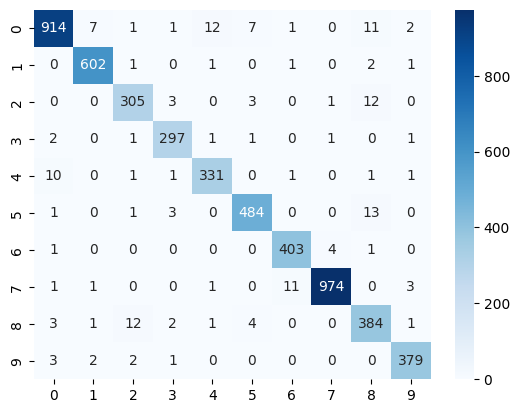

In [ ]:
import seaborn as sns
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot =True, fmt ='d', cmap='Blues', cbar='False')

## 11. Grafik akurasi & loss

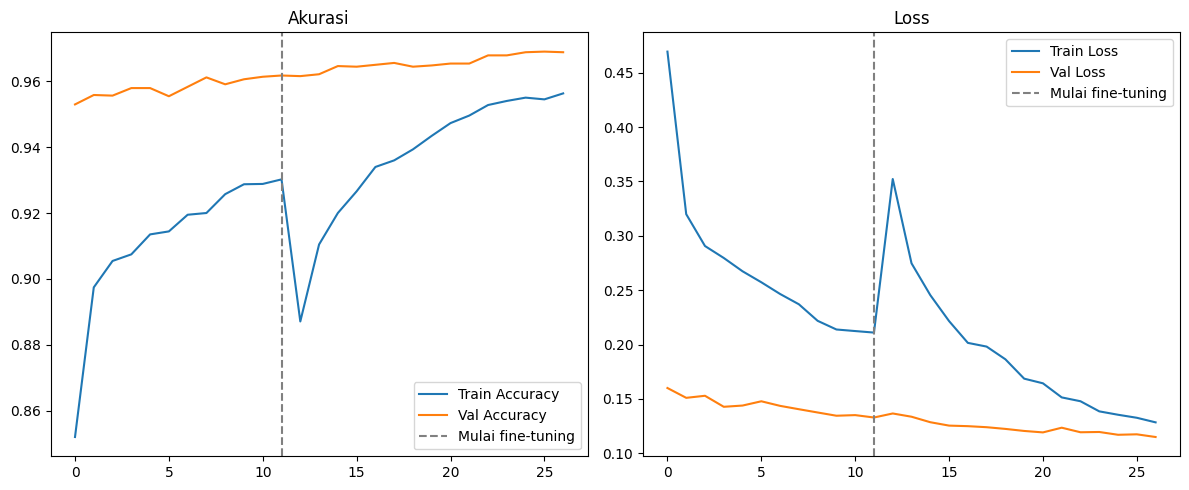

In [ ]:
acc = history_head.history["accuracy"] + history_fine.history["accuracy"]
val_acc = history_head.history["val_accuracy"] + history_fine.history["val_accuracy"]
loss = history_head.history["loss"] + history_fine.history["loss"]
val_loss = history_head.history["val_loss"] + history_fine.history["val_loss"]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label="Train Accuracy")
plt.plot(val_acc, label="Val Accuracy")
plt.axvline(EPOCHS_HEAD - 1, color="gray", linestyle="--", label="Mulai fine-tuning")
plt.legend(); plt.title("Akurasi")

plt.subplot(1, 2, 2)
plt.plot(loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.axvline(EPOCHS_HEAD - 1, color="gray", linestyle="--", label="Mulai fine-tuning")
plt.legend(); plt.title("Loss")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_history.png"))
plt.show()

## 12. Download hasil model yang sudah dibuat


In [ ]:
import shutil
from google.colab import files

shutil.make_archive("/content/satwavision_output", 'zip', "/content/drive/MyDrive/satwavision")
files.download("/content/satwavision_output.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>